#  Data Preprocessing Project
### Name: Nija Lathiya
### Topic: Missing Value Imputation, Outlier Detection, Normalization, Standardization & Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

#  Question 1: Exploratory Data Analysis (EDA)

In this section, the Titanic dataset is explored to understand its structure, data types, missing values, and statistical summary.

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Observation:
The Titanic dataset contains both numerical and categorical columns, and missing values are mainly present in Age, Cabin, and Embarked columns.

# Question 2: Missing Value Visualization

This section visualizes missing values using a heatmap and a percentage bar chart to identify incomplete data in the dataset.

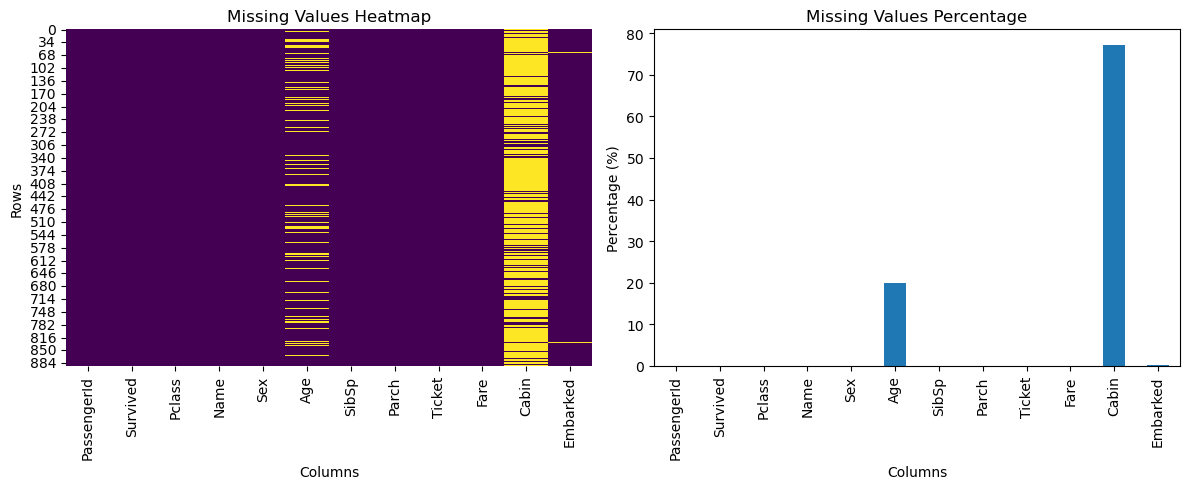

In [10]:
plt.figure(figsize=(12,5))

# Heatmap
plt.subplot(1,2,1)
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

# Bar Chart
plt.subplot(1,2,2)
missing_percent = df.isnull().mean() * 100
missing_percent.plot(kind='bar')
plt.title("Missing Values Percentage")
plt.xlabel("Columns")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

### Observation:
Cabin has the highest missing values, while Age and Embarked contain relatively fewer missing values.

# Question 3: Mean, Median and Mode Imputation

This section compares Mean, Median, and Mode imputation methods for handling missing values in the Age column and analyzes their impact on data distribution.

In [11]:
df_mean = df.copy()
df_median = df.copy()
df_mode = df.copy()

In [12]:
df_mean['Age'] = df_mean['Age'].fillna(df_mean['Age'].mean())

df_median['Age'] = df_median['Age'].fillna(df_median['Age'].median())

df_mode['Age'] = df_mode['Age'].fillna(df_mode['Age'].mode()[0])

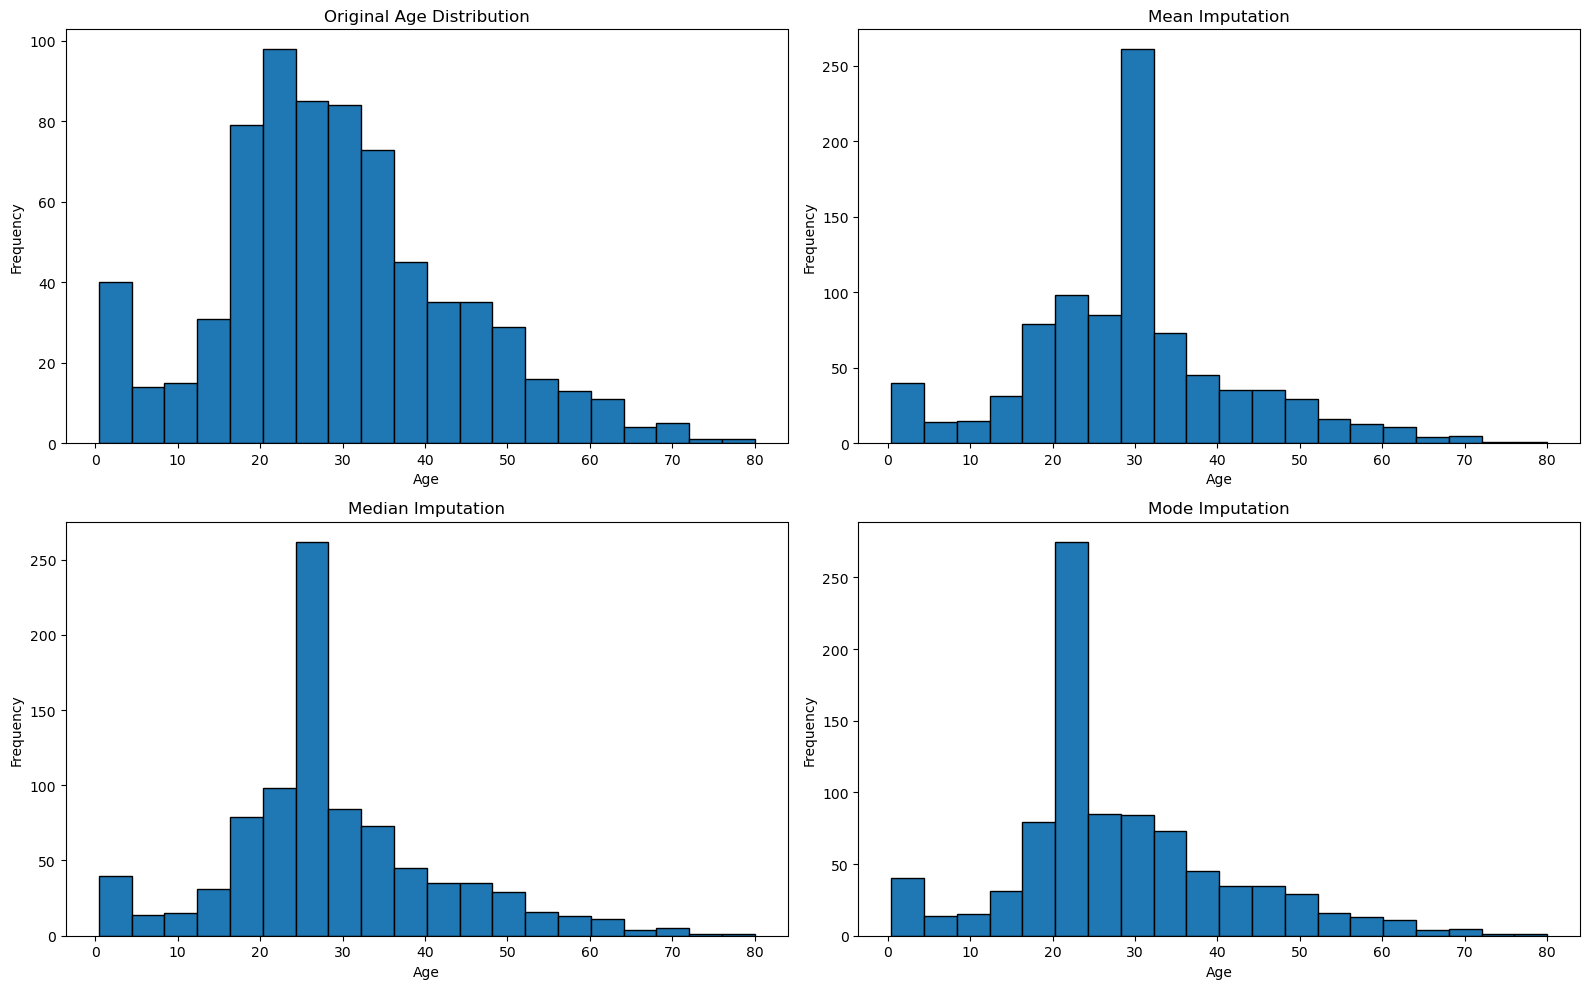

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
plt.hist(df['Age'].dropna(), bins=20,edgecolor="black")
plt.title("Original Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Mean Imputation
plt.subplot(2,2,2)
plt.hist(df_mean['Age'], bins=20,edgecolor="black")
plt.title("Mean Imputation")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Median Imputation
plt.subplot(2,2,3)
plt.hist(df_median['Age'], bins=20,edgecolor="black")
plt.title("Median Imputation")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Mode Imputation
plt.subplot(2,2,4)
plt.hist(df_mode['Age'], bins=20,edgecolor="black")
plt.title("Mode Imputation")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [14]:
print("Original Mean:", df['Age'].mean())
print("Original Std:", df['Age'].std())

print("\nMean Imputation Mean:", df_mean['Age'].mean())
print("Mean Imputation Std:", df_mean['Age'].std())

print("\nMedian Imputation Mean:", df_median['Age'].mean())
print("Median Imputation Std:", df_median['Age'].std())

print("\nMode Imputation Mean:", df_mode['Age'].mean())
print("Mode Imputation Std:", df_mode['Age'].std())

Original Mean: 29.69911764705882
Original Std: 14.526497332334044

Mean Imputation Mean: 29.69911764705882
Mean Imputation Std: 13.002015226002884

Median Imputation Mean: 29.36158249158249
Median Imputation Std: 13.019696550973194

Mode Imputation Mean: 28.566969696969696
Mode Imputation Std: 13.199571767746487


### Observation:
Median imputation preserves the original Age distribution better because it is less affected by outliers.

#  Question 4: SimpleImputer from Scikit-Learn

In this question, missing values are handled using SimpleImputer. Numerical columns are imputed using the median strategy, while categorical columns are imputed using the most frequent value.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

#### Features and Target

In [16]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#### Select Columns

In [18]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = ['Embarked', 'Cabin']

#### Create Imputers

In [19]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

#### Numerical Imputation

In [20]:
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

#### Categorical Imputation

In [21]:
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

#### Check Missing Values

In [22]:
print("Missing Values in Train Dataset")
X_train.isnull().sum()

Missing Values in Train Dataset


PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

#### Check Missing Values

In [23]:
print("Missing Values in Test Dataset")
X_test.isnull().sum()

Missing Values in Test Dataset


PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

### Observation:
SimpleImputer successfully filled all missing values, making the dataset ready for machine learning.

# Question 5: Per-Class (Group-wise) Imputation

In this question, missing Age values are filled using the mean age of each survival group. This helps preserve differences between passengers who survived and those who did not survive.

In [24]:
survived_mean = df[df['Survived'] == 1]['Age'].mean()
not_survived_mean = df[df['Survived'] == 0]['Age'].mean()

print("Mean Age of Survived Passengers:", survived_mean)
print("Mean Age of Non-Survived Passengers:", not_survived_mean)

Mean Age of Survived Passengers: 28.343689655172415
Mean Age of Non-Survived Passengers: 30.62617924528302


In [25]:
df_group = df.copy()
df_group['Age'] = df_group.groupby('Survived')['Age'].transform(lambda x: x.fillna(x.mean()))

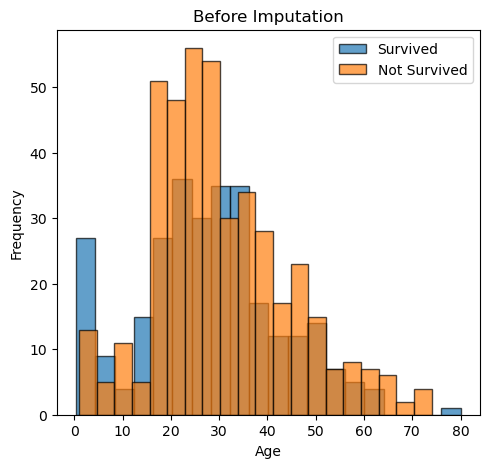

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df[df['Survived']==1]['Age'].dropna(),bins=20,alpha=0.7,label='Survived',edgecolor='black', linewidth=1)
plt.hist(df[df['Survived']==0]['Age'].dropna(),bins=20,alpha=0.7,label='Not Survived',edgecolor='black', linewidth=1)
plt.title("Before Imputation")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()

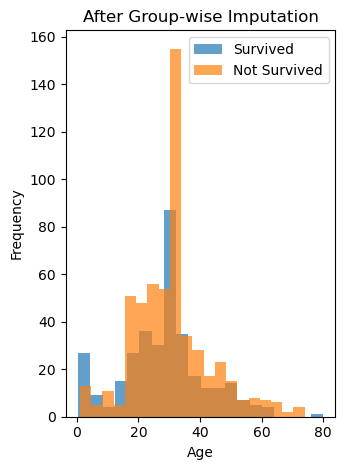

In [27]:
plt.subplot(1,2,2)

plt.hist(df_group[df_group['Survived']==1]['Age'],bins=20,alpha=0.7,label='Survived')
plt.hist(df_group[df_group['Survived']==0]['Age'],bins=20,alpha=0.7,label='Not Survived')
plt.title("After Group-wise Imputation")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

### Observation:
The average age differs between survivors and non-survivors, so group-wise imputation preserves class-specific information better than a single global mean.

#  Question 6: Building a Scikit-Learn Pipeline
In this question, a preprocessing pipeline is created using SimpleImputer and StandardScaler to automate missing value handling and feature scaling.

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [29]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

In [30]:
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

In [31]:
X_train_pipe = pipe.fit_transform(X_train[num_cols])
X_test_pipe = pipe.transform(X_test[num_cols])

In [32]:
pd.DataFrame(X_train_pipe,columns=num_cols).mean()

PassengerId    8.482603e-17
Pclass         9.355812e-17
Age            1.746418e-17
SibSp          1.746418e-17
Parch          2.245395e-17
Fare           5.363999e-17
dtype: float64

In [33]:
pd.DataFrame(X_train_pipe,columns=num_cols).std()

PassengerId    1.000703
Pclass         1.000703
Age            1.000703
SibSp          1.000703
Parch          1.000703
Fare           1.000703
dtype: float64

### Observation:
The pipeline successfully imputed missing values and standardized the numerical features, resulting in mean values close to 0 and standard deviations close to 1.

#  Question 7: Normalization vs Standardization

In this question, MinMaxScaler and StandardScaler are applied to numerical features to compare their effect on data distribution.

In [34]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [35]:
features = df[['Age', 'Fare']].copy()
features['Age'] = features['Age'].fillna(features['Age'].median())
features['Fare'] = features['Fare'].fillna(features['Fare'].median())

features.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [36]:
minmax = MinMaxScaler()
normalized_data = minmax.fit_transform(features)

normalized_df = pd.DataFrame(normalized_data,columns=['Age','Fare'])
normalized_df.head()

,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


In [37]:
standard = StandardScaler()

standardized_data = standard.fit_transform(features)

standardized_df = pd.DataFrame(standardized_data,columns=['Age', 'Fare'])
standardized_df.head(10)

,Age,Fare
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337
5,-0.104637,-0.478116
6,1.893459,0.395814
7,-2.102733,-0.224083
8,-0.181487,-0.424256
9,-1.180535,-0.042956


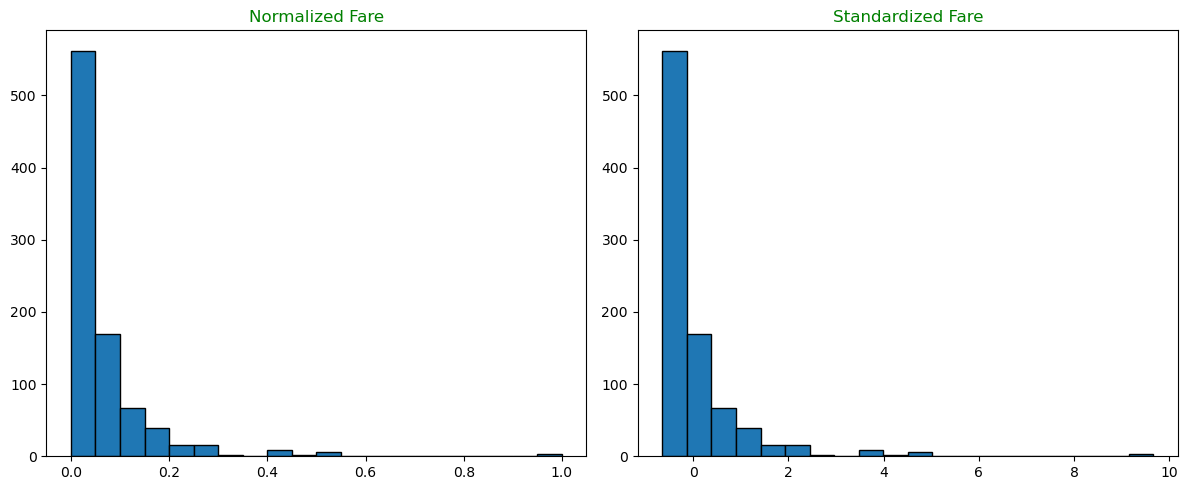

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(normalized_df['Fare'], bins=20,edgecolor="black")
plt.title("Normalized Fare",color ="green")

plt.subplot(1,2,2)
plt.hist(standardized_df['Fare'], bins=20,edgecolor="black")
plt.title("Standardized Fare",color="green")

plt.tight_layout()
plt.show()

### Observation:
Normalization scales values between 0 and 1, while standardization transforms data to have mean 0 and standard deviation 1.

#  Question 8: Outlier Detection using IQR Method

In this question, outliers in the Fare column are identified and removed using the Interquartile Range (IQR) method. The distribution is then compared before and after outlier removal.

In [39]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1
Q1, Q3, IQR

(np.float64(7.9104), np.float64(31.0), np.float64(23.0896))

In [40]:
lower= Q1 - 1.5 * IQR
upper= Q3 + 1.5 * IQR

lower, upper

(np.float64(-26.724), np.float64(65.6344))

#### Detect Outliers

In [41]:
outliers = df[(df['Fare'] < lower) |(df['Fare'] > upper)]
outliers.shape

(116, 12)

#### Remove Outliers

In [42]:
remove = df[(df['Fare'] >= lower) &(df['Fare'] <= upper)]
remove.shape

(775, 12)

Text(0, 0.5, 'Fare')

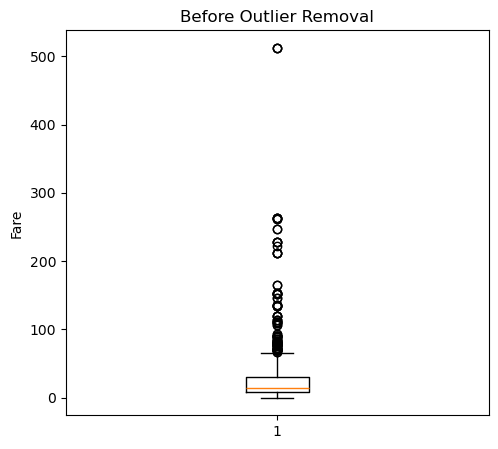

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.boxplot(df['Fare'].dropna())
plt.title("Before Outlier Removal")

plt.ylabel("Fare")

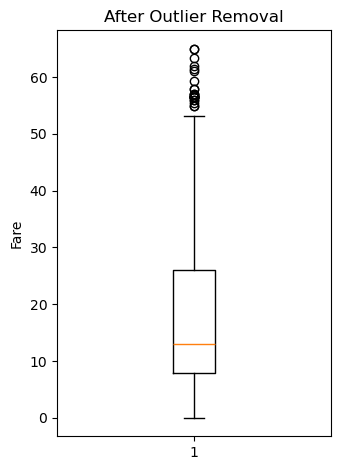

In [44]:
plt.subplot(1,2,2)
plt.boxplot(remove['Fare'])
plt.title("After Outlier Removal")
plt.ylabel("Fare")
plt.tight_layout()

plt.show()

### Observation:
Several extreme Fare values were identified as outliers, and removing them reduced the spread of the data.

#  Question 9: Outlier Detection using Z-Score Method

In this question, outliers in the Fare column are detected and removed using the Z-Score method. The distribution is compared before and after removing outliers.

In [45]:
from scipy import stats
import numpy as np

In [46]:
z_scores = np.abs(stats.zscore(df['Fare']))

#### Detect Outliers

In [47]:
outliers = df[z_scores > 3]
outliers.shape

(20, 12)

#### Remove Outliers

In [48]:
df_zscore = df[z_scores <= 3]
df_zscore.shape

(871, 12)

Text(0, 0.5, 'Fare')

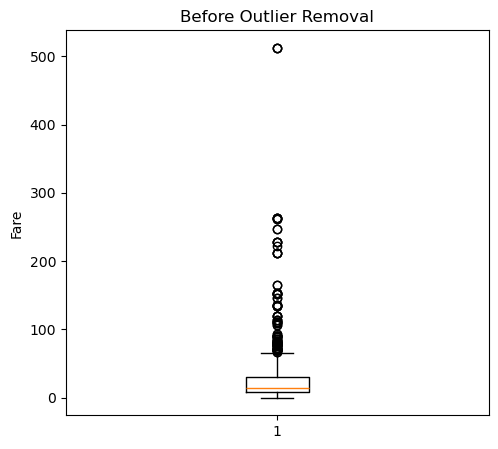

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.boxplot(df['Fare'].dropna())
plt.title("Before Outlier Removal")
plt.ylabel("Fare")

NameError: name 'Plt' is not defined

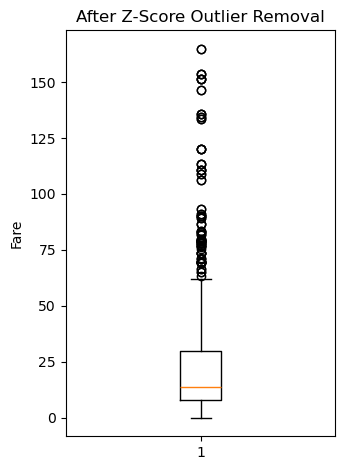

In [82]:
plt.subplot(1,2,2)
plt.boxplot(df_zscore['Fare'])
plt.title("After Z-Score Outlier Removal")
plt.ylabel("Fare")
plt.tight_layout()
Plt.show()

#### Observation:

The Z-Score method successfully identified and removed outliers from the Fare column, resulting in a more normalized data distribution.

# Question 10 : Preprocessing Pipeline

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [52]:
X = df.drop("Survived",axis = 1)
y = df["Survived"]

In [53]:
num_cols = X.select_dtypes(include = np.number).columns
cat_cols = X.select_dtypes(include="object").columns

In [54]:
num_pipeline = Pipeline([("imputer",SimpleImputer (strategy ="median")),("scaler",StandardScaler())])
cat_pipeline = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])

In [55]:
preprocessor = ColumnTransformer([("num", num_pipeline,num_cols),("cat",cat_pipeline,cat_cols)])

In [56]:
preprocessor.fit(X)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [57]:
preprocessor.transform

<bound method ColumnTransformer.transform of ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object'))])>

#### Observation:
The data was successfully preprocessed using Pipeline and ColumnTransformer.

#  Thank You

Thank you for reviewing my project. This project provided valuable hands-on experience in data preprocessing and machine learning, helping me strengthen my analytical and problem-solving skills.